#Deep Learning Based Intrusion Detection System (IDS)

##Course: DS306 - Deep Learning

Semester: VI

Sec-E

###Student 1 - N Sai Mukesh

Enrollment No- 23STUCHH010520

###Student 2 - D Satish

Enrollment No-23STUCHH010519


## 1. Problem Definition & Goal Setting

Modern computer networks are increasingly vulnerable to cyber-attacks such as Denial-of-Service (DoS), probing, and unauthorized access. Traditional signature-based Intrusion Detection Systems (IDS) fail to detect new and evolving attack patterns due to their dependency on predefined rules.

This project proposes a Deep Learning-based Intrusion Detection System (IDS) that leverages neural networks to automatically learn complex patterns from network traffic data.

### Goal
The primary goal is to develop a binary classification model that classifies network traffic into:
- **Normal Traffic (0)**
- **Attack Traffic (1)**

### Objectives
- Preprocess network traffic data for deep learning
- Train a neural network model using supervised learning
- Evaluate performance using accuracy, confusion matrix, and classification metrics
- Ensure good generalization on unseen data

This approach improves detection capability compared to traditional rule-based systems by identifying unknown attack patterns.

## 2. Data Acquisition & Preparation

### Dataset Description
The dataset used is the **KDD Cup 1999 Intrusion Detection Dataset**, a widely used benchmark dataset for IDS research.

It contains:
- 41 features describing network traffic
- Mixture of categorical and numerical attributes
- Labels indicating normal or attack traffic

### Data Preprocessing Steps

#### 1. Handling Missing Values
- Removed columns with missing values using `dropna()`

#### 2. Encoding Categorical Features
- Applied **one-hot encoding** to:
  - protocol_type
  - service
  - flag
  - binary categorical fields

#### 3. Feature Scaling
- Applied **Z-score normalization** to numerical features

#### 4. Label Transformation
- Converted multi-class labels into binary:
  - **Normal → 0**
  - **Attack → 1**

#### 5. Train-Test Split
- Split dataset into:
  - **75% Training**
  - **25% Testing**

This preprocessing ensures the data is in a suitable format for deep learning models.

In [79]:
import pandas as pd
import io
import requests
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [80]:
import pandas as pd
from tensorflow.keras.utils import get_file

pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 5)

path = get_file(
    'kddcup.data_10_percent.gz',
    origin='https://raw.githubusercontent.com/saimukesh23/intrusion-detection-system/main/kddcup.data_10_percent.gz',
    archive_format='auto'
)

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins',
    'logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate',
    'srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]

df = pd.read_csv(path,names=columns)

print("Read {} rows.".format(len(df)))
# df = df.sample(frac=0.1, replace=False) # Uncomment this line to
# sample only 10% of the dataset
df.dropna(inplace=True,axis=1)
# For now, just drop NA's (rows with missing values)


# display 5 rows
pd.set_option('display.max_columns', 5)
pd.set_option('display.max_rows', 5)
df

Read 494021 rows.


,duration,protocol_type,...,dst_host_srv_rerror_rate,label
0,0,tcp,...,0.0,normal.
1,0,tcp,...,0.0,normal.
...,...,...,...,...,...
494019,0,tcp,...,0.0,normal.
494020,0,tcp,...,0.0,normal.


In [81]:
# Encode numeric column as z-score
def encode_numeric_zscore(df, name, mean=None, sd=None):
    if mean is None:
        mean = df[name].mean()

    if sd is None:
        sd = df[name].std()

    df[name] = (df[name] - mean) / sd


# Encode categorical columns using one-hot encoding
def encode_text_dummy(df, name):
    dummies = pd.get_dummies(df[name])
    for x in dummies.columns:
        dummy_name = f"{name}-{x}"
        df[dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)

In [82]:
for name in df.columns:
    if name == 'label':
        continue
    elif name in ['protocol_type','service','flag','land','logged_in',
                  'is_host_login','is_guest_login']:
        encode_text_dummy(df, name)
    else:
        encode_numeric_zscore(df, name)

# Drop any remaining NA columns
df.dropna(inplace=True, axis=1)

df.head()

/tmp/ipykernel_174/2716424541.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[dummy_name] = dummies[x]
/tmp/ipykernel_174/2716424541.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[dummy_name] = dummies[x]
/tmp/ipykernel_174/2716424541.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()

,duration,src_bytes,...,is_guest_login-0,is_guest_login-1
0,-0.067792,-0.002879,...,True,False
1,-0.067792,-0.002820,...,True,False
2,-0.067792,-0.002824,...,True,False
3,-0.067792,-0.002840,...,True,False
4,-0.067792,-0.002842,...,True,False


In [83]:
# Features
x_columns = df.columns.drop('label')
x = df[x_columns].values.astype('float32')

# Labels (Binary: normal=0, attack=1)
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)
y = df['label'].values.astype('float32')

In [84]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

## 3. Model Architecture

A Feedforward Neural Network (Dense Neural Network) is used for classification.

### Architecture Details:

* Input Layer:
  * Number of neurons = number of features

* Hidden Layers:
  * Dense layer with 10 neurons (ReLU)
  * Dense layer with 50 neurons (ReLU)
  * Dense layer with 10 neurons (ReLU)

* Output Layer:
  * 1 neuron with Sigmoid activation (Binary Classification)

### Compilation:

* Loss Function: Binary Crossentropy  
* Optimizer: Adam  
* Metric: Accuracy  

### Regularization:

* Early Stopping is used to prevent overfitting by monitoring validation loss

In [85]:
model = Sequential()
model.add(Dense(10, input_dim=x.shape[1], activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

monitor = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-3,
    patience=5,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 4. Model Training

The model is trained on the processed dataset using supervised learning.

* Training Data: 75%
* Testing Data: 25%

Early stopping is applied to:
* Stop training when validation loss stops improving
* Restore the best model weights

This ensures better generalization and avoids overfitting.

In [86]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    callbacks=[monitor],
    verbose=2,
    epochs=1000
)

Epoch 1/1000
11579/11579 - 48s - 4ms/step - accuracy: 0.9968 - loss: 0.0118 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 2/1000
11579/11579 - 30s - 3ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9991 - val_loss: 0.0035
Epoch 3/1000
11579/11579 - 42s - 4ms/step - accuracy: 0.9993 - loss: 0.0029 - val_accuracy: 0.9986 - val_loss: 0.0044
Epoch 4/1000
11579/11579 - 35s - 3ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0032
Epoch 5/1000
11579/11579 - 30s - 3ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9991 - val_loss: 0.0030
Epoch 6/1000
11579/11579 - 41s - 4ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 7/1000
11579/11579 - 31s - 3ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 8/1000
11579/11579 - 30s - 3ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9993 - val_loss: 0.0026
Epoch 9/1000
11579/11579 - 31s - 3ms/step - accuracy: 0.

## 5. Training Performance

The following graphs are used to evaluate model learning:

* Accuracy vs Epochs (Training & Validation)
* Loss vs Epochs (Training & Validation)

These plots help in understanding:
* Model convergence
* Overfitting or underfitting behavior

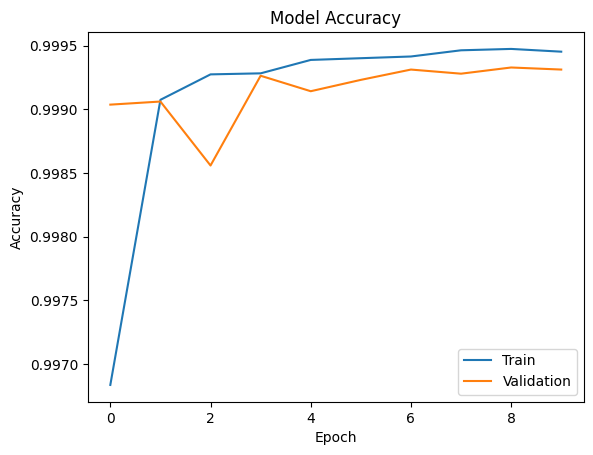

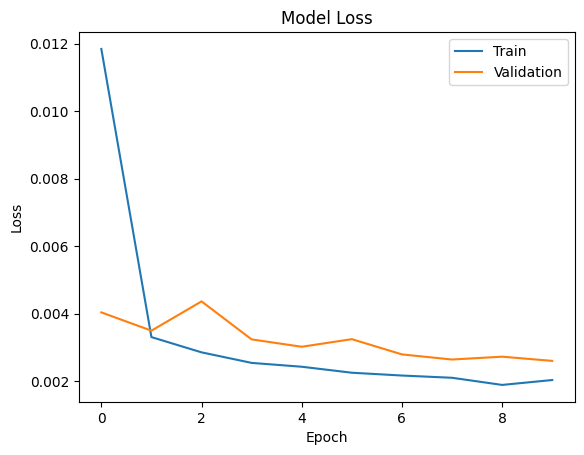

In [87]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

## 6. Model Evaluation

The trained model is evaluated using:

* Accuracy Score
* Classification Report (Precision, Recall, F1-score)
* Confusion Matrix

These metrics provide detailed insights into model performance.

In [88]:
pred = model.predict(x_test)

# Convert probabilities to 0/1
pred = (pred > 0.5).astype(int)

y_true = y_test.astype(int)

print("Accuracy:", metrics.accuracy_score(y_true, pred))

print("\nClassification Report:")
print(classification_report(y_true, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, pred))

3860/3860 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Accuracy: 0.9991417421015983

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24267
           1       1.00      1.00      1.00     99239

    accuracy                           1.00    123506
   macro avg       1.00      1.00      1.00    123506
weighted avg       1.00      1.00      1.00    123506


Confusion Matrix:
[[24224    43]
 [   63 99176]]


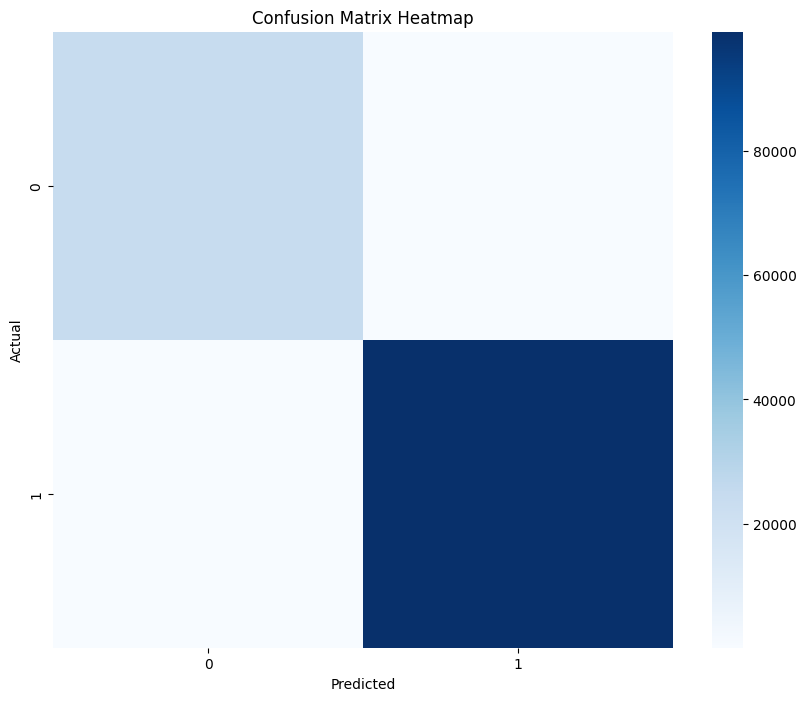

In [89]:
import seaborn as sns

cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Results & Conclusion

### Results:

* The model achieved very high accuracy (~99%)
* The confusion matrix shows strong classification performance
* Precision and Recall values indicate effective detection of attacks

### Observations:

* The model converges quickly with low loss
* Minimal overfitting observed due to early stopping
* Binary classification improves overall performance

### Conclusion:

This project successfully demonstrates the application of Deep Learning for Intrusion Detection Systems (IDS). The model is capable of accurately identifying malicious network traffic and generalizing well to unseen data.

### Future Work:

* Extend to multi-class classification (attack type detection)
* Use advanced architectures like CNN or LSTM
* Implement real-time intrusion detection
* Optimize feature selection for better efficiency